In [28]:
import os
import re
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [29]:
def extract_edge_profile(img_path):
    img  = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    _, thresh = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        print('No contours found')
        return None
    
    wafer = max(contours, key=cv2.contourArea)
    M = cv2.moments(wafer)
    if M['m00'] == 0:
        return None
    
    cx = int(M['m10'] / M['m00'])
    cy = int(M['m01'] / M['m00'])
    _, radius = cv2.minEnclosingCircle(wafer)
    radius = int(radius * 0.92)
    
    profile = []
    for i in range(360):
        angle = np.radians(i)
        x = int(cx + radius * np.cos(angle))
        y = int(cy + radius * np.sin(angle))
        x = np.clip(x, 0, img.shape[1] - 1)
        y = np.clip(y, 0, img.shape[0] - 1)
        profile.append(gray[y, x] / 255.0)
    
    return np.array(profile, dtype=np.float32)

In [ ]:
class WaferDataset(Dataset):
    def __init__(self, data_dir):
        self.samples = []
        
        for fname in os.listdir(data_dir):
            if not fname.endswith('.png'):
                continue
            
            # Extract angle from filename e.g. wafer_0042_angle_042.png
            match = re.search(r'angle_(\d+)', fname)
            if not match:
                continue
            
            angle_deg = int(match.group(1))
            angle_rad = np.radians(angle_deg)
            
            path    = os.path.join(data_dir, fname)
            profile = extract_edge_profile(path)
            if profile is None:
                continue
            
            # Encode angle as sin/cos so 0° and 360° are treated the same
            label = np.array([np.sin(angle_rad), 
                              np.cos(angle_rad)], dtype=np.float32)
            self.samples.append((profile, label))
        
        print(f"Loaded {len(self.samples)} samples")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        profile, label = self.samples[idx]
        return torch.tensor(profile), torch.tensor(label)

In [ ]:
class NotchCNN(nn.Module):
    """
    1D CNN: input is 360-point edge profile, output is (sin, cos) of notch angle.
    Small enough to run fast on CPU.
    """
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, padding=3),  # 360 -> 360
            nn.ReLU(),
            nn.MaxPool1d(2),                              # 360 -> 180
            nn.Conv1d(16, 32, kernel_size=5, padding=2), # 180 -> 180
            nn.ReLU(),
            nn.MaxPool1d(2),                              # 180 -> 90
            nn.Conv1d(32, 64, kernel_size=3, padding=1), # 90  -> 90
            nn.ReLU(),
            nn.MaxPool1d(2),                              # 90  -> 45
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * 45, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)  
        )
    
    def forward(self, x):
        x = x.unsqueeze(1)      
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [32]:
def train(data_dir, model_path='notch_model.pth', epochs=50):
    dataset = WaferDataset(data_dir)
    
    train_data, val_data = train_test_split(dataset.samples, 
                                            test_size=0.2, 
                                            random_state=42)
    
    def make_loader(samples):
        ds = WaferDataset.__new__(WaferDataset)
        ds.samples = samples
        return DataLoader(ds, batch_size=32, shuffle=True)
    
    train_loader = make_loader(train_data)
    val_loader   = make_loader(val_data)
    
    model     = NotchCNN()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    
    best_val_loss = float('inf')
    
    for epoch in range(epochs):
        # Train
        model.train()
        train_loss = 0
        for profiles, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(profiles)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        # Validate
        model.eval()
        val_loss = 0
        angle_errors = []
        with torch.no_grad():
            for profiles, labels in val_loader:
                outputs  = model(profiles)
                val_loss += criterion(outputs, labels).item()
                
                # Convert sin/cos back to angle and measure error
                pred_angles  = torch.atan2(outputs[:,0], outputs[:,1])
                true_angles  = torch.atan2(labels[:,0],  labels[:,1])
                errors = torch.abs(pred_angles - true_angles)
                # Wrap errors to 0..π
                errors = torch.where(errors > np.pi, 
                                     2*np.pi - errors, errors)
                angle_errors.extend(np.degrees(errors.numpy()))
        
        avg_train = train_loss / len(train_loader)
        avg_val   = val_loss   / len(val_loader)
        avg_err   = np.mean(angle_errors)
        
        print(f"Epoch {epoch+1:3d}/{epochs} | "
              f"Train: {avg_train:.4f} | "
              f"Val: {avg_val:.4f} | "
              f"Angle error: {avg_err:.2f}°")
        
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(model.state_dict(), model_path)
            print(f"  Saved best model")
    
    print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")
    return model

In [ ]:
def predict_notch_angle(model, img_path):
    """Run inference on a single image, return notch angle in radians."""
    profile = extract_edge_profile(img_path)
    if profile is None:
        return None
    
    model.eval()
    with torch.no_grad():
        x      = torch.tensor(profile).unsqueeze(0)  # batch of 1
        output = model(x)
        angle  = torch.atan2(output[0,0], output[0,1]).item()
    
    return angle


if __name__ == '__main__':
    DATA_DIR   = r'C:\Users\metro\OneDrive\Desktop\IE574\Project 3\Vision_Training_Data' # Update Location to where training images are saved
    MODEL_PATH = r'notch_model.pth' # Update to where you want model saved
    
    train(DATA_DIR, MODEL_PATH, epochs=50)

Loaded 360 samples
Epoch   1/50 | Train: 0.5068 | Val: 0.5106 | Angle error: 95.29°
  Saved best model
Epoch   2/50 | Train: 0.5012 | Val: 0.4988 | Angle error: 94.67°
  Saved best model
Epoch   3/50 | Train: 0.4820 | Val: 0.4632 | Angle error: 26.30°
  Saved best model
Epoch   4/50 | Train: 0.4234 | Val: 0.3475 | Angle error: 10.53°
  Saved best model
Epoch   5/50 | Train: 0.2342 | Val: 0.0660 | Angle error: 6.79°
  Saved best model
Epoch   6/50 | Train: 0.0550 | Val: 0.0153 | Angle error: 4.50°
  Saved best model
Epoch   7/50 | Train: 0.0384 | Val: 0.0036 | Angle error: 2.24°
  Saved best model
Epoch   8/50 | Train: 0.0333 | Val: 0.0046 | Angle error: 2.09°
Epoch   9/50 | Train: 0.0295 | Val: 0.0024 | Angle error: 1.95°
  Saved best model
Epoch  10/50 | Train: 0.0248 | Val: 0.0079 | Angle error: 2.35°
Epoch  11/50 | Train: 0.0277 | Val: 0.0032 | Angle error: 1.82°
Epoch  12/50 | Train: 0.0251 | Val: 0.0020 | Angle error: 2.17°
  Saved best model
Epoch  13/50 | Train: 0.0230 | Val: 0.

Edge profile extracted successfully, shape: (360,)


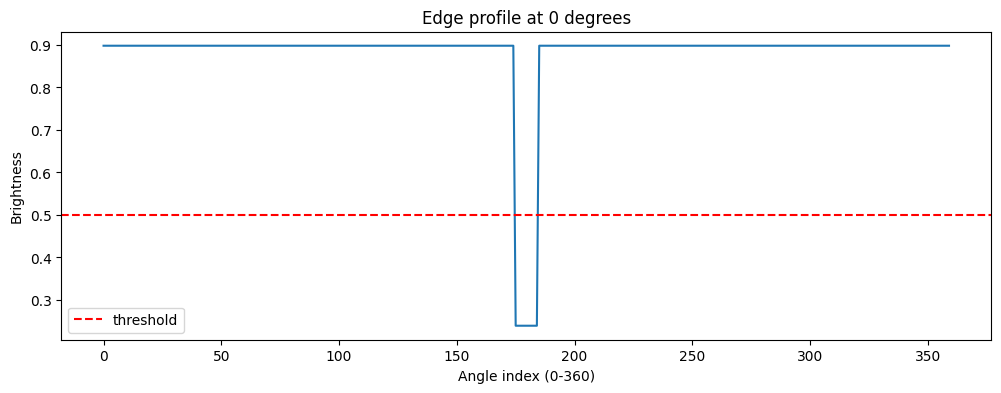

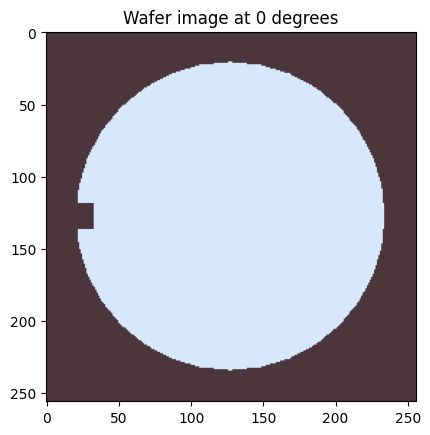

In [ ]:
test_img = r'C:\Users\metro\OneDrive\Desktop\IE574\Project 3\Vision_Training_Data\wafer_0000_angle_000.png' # Update Location to where wafer_0000_angle_000.png is saved (first training image)
profile = extract_edge_profile(test_img)

if profile is not None:
    print(f'Edge profile extracted successfully, shape: {profile.shape}')
    plt.figure(figsize=(12, 4))
    plt.plot(profile)
    plt.title('Edge profile at 0 degrees')
    plt.xlabel('Angle index (0-360)')
    plt.ylabel('Brightness')
    plt.axhline(y=0.5, color='r', linestyle='--', label='threshold')
    plt.legend()
    plt.show()
    
    # Also show the actual image
    img = cv2.imread(test_img)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure()
    plt.imshow(img_rgb)
    plt.title('Wafer image at 0 degrees')
    plt.show()
else:
    print('ERROR: could not extract profile')